In [30]:
import itertools
import csv

import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import torch


from torch import exp, sin, cos
from tqdm import tqdm_notebook
from ipywidgets import interact, FloatSlider, Dropdown
from torchquad import (
    set_up_backend,
    Trapezoid,
    Simpson,
    MonteCarlo,
    Gaussian,
    GaussLegendre,
)

## Memorijska funkcija s vezanjem $\theta(k_c-|k-k'|)$


In [2]:
set_up_backend("torch", data_type="float32")
tp = MonteCarlo()
tp2 = Trapezoid()

c:\Users\Patrik\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\__init__.py:1144: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\tensor\python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


## Konstante i osnovne funkcije

In [4]:
kb = 8.6173303 * 10 ** (-5)
hbar = 6.582119569 * 10 ** (-16)
pi = np.pi

alpha_op = 0.6
alpha_ac = 1
hbar_w_op = torch.Tensor([0.4]).to("cuda")
eta_0 = 1 * 10 ** (-3)
M = 0.0
Kf_ev = 0.5  # eV
vf = 4 * 10**5
a = 100 ** (1 / 3) * 10 ** (-10)
T_0 = 250
T_F = Kf_ev / kb
W = 1  # band width
C = 1.2  # cutoff for coupling

Kf_ = Kf_ev / hbar / vf * a  # Fermi unitless
K_c = C / hbar / vf * a  # cutoff for coupling unitless
K_w = W / hbar / vf * a  # cutoff 1eV unitless
c_s_tilde = 0.03  # hbar_w_ac_max / hbar / vf * a
hbar_w_ac_max = c_s_tilde * hbar * vf / a
G_op2 = alpha_op
G_ac2 = alpha_ac * hbar * vf / a
Ef = torch.sqrt(torch.FloatTensor([Kf_ev**2 + M**2])).to("cuda")

In [5]:
def arrays_to_csv(array1, array2, name):
    with open(f"{name}.csv", "w", newline="") as file:
        writer = csv.writer(file)
        for a1, a2 in zip(array1, array2):
            writer.writerow([round(a1, 5), a2])


def read_from_csv(name):
    col_1 = []
    col_2 = []
    with open(f"{name}.csv", "r", newline="") as file:
        reader = csv.reader(file)
        for a1, a2 in reader:
            col_1.append(float(a1))
            col_2.append(float(a2))
    return col_1, col_2

In [6]:
def fermi_dirac(E, Ef, T):
    if T > 0:
        return torch.where(
            E > Ef,
            exp((-E + Ef) / (kb * T)) / (exp((-E + Ef) / (kb * T)) + 1),
            1 / (exp((E - Ef) / (kb * T)) + 1),
        )
    else:
        return torch.where(E > Ef, 0, 1)


def d_fermi_dirac(E, Ef, T):
    return 1 / kb / T * fermi_dirac(E, Ef, T) * (1 - fermi_dirac(E, Ef, T))


def bose_einstein(E, T):
    if T == 0:
        return torch.where(E > 0, 0.0, -1.0)  # n_B(-|E|) -> -1
    return torch.where(
        E > 0,
        exp(-E / (kb * T)) / (1 - exp(-E / (kb * T))),  # stable for large +E
        1.0 / (exp(E / (kb * T)) - 1.0),  # = -1 - n_B(|E|), stable for -E
    )


def chemical_potential(T):
    return (
        Ef
        - pi**2 / 6 * (2 * Ef**2 - M**2) / Ef / (Ef**2 - M**2) * (kb * T) ** 2
        - 7 / 360 * pi**4 * 3 * M**4 / Ef / (Ef**2 - M**2) ** 3 * (kb * T) ** 4
    )


def eps(K):
    arg = hbar**2 * vf**2 / a**2 * K**2 + M**2
    if isinstance(K, torch.Tensor):
        return torch.sqrt(arg)
    else:
        return np.sqrt(arg)


def eff_concetration(T):
    def integrand(k):
        return 2 / hbar / vf / a**2 * fermi_dirac(eps(k), Ef, T) * k

    return (
        4
        * pi
        / 3
        * 2
        / (2 * pi) ** 3
        * vf**2
        * integrate.quad(integrand, 0, K_w, limit=80000)[0]
    )


def coupling(K_c, abs_dK):
    return G_op2 / (1 + exp(-10000 * (K_c - abs_dK)))

In [ ]:
print(eff_concetration(0))  # T=0 numerički
print(4 * pi / 3 * 2 / (2 * pi) ** 3 * Kf_ev**2 / hbar**3 / vf)  # T=0 analitički

7.402215595922252e+37
7.402215343214329e+37


In [10]:
ws_0 = torch.arange(-1.50, 2, 0.01)


def calculate_integral_points(
    mem_fn, real_sum, imag_sum, hbar_w_ph, T=T_0, eta=eta_0, ws=ws_0, u=Kf_ev, K_c=K_c
):

    result_real = []

    result_imag = []

    for w in tqdm_notebook(ws):

        result_real.append(
            mem_fn(real_sum, w, hbar_w_ph, u, T=T, eta=eta, K_c=K_c).to("cpu")
        )

        result_imag.append(
            mem_fn(imag_sum, w, hbar_w_ph, u, T=T, eta=eta, K_c=K_c).to("cpu")
        )

    return result_real, result_imag


def setup_plot(real=True, imag=True, x_lim=[0.0, 0.05], y_lim=[0, 0.06]):

    fig, ax1 = plt.subplots()

    ax1.set_xlabel(r"$\hbar \omega [eV]$")

    if real:

        ax1.set_ylabel(r"$\hbar Re\{M_x\} [eV]$")

    else:

        ax1.set_ylabel(r"$\hbar Im\{M_x\} [eV]$")

    ax1.set_xlim(x_lim)

    ax1.set_ylim(y_lim)

    if imag and real:

        ax2 = ax1.twinx()

        ax2.set_ylabel(r"$\hbar Im\{M_x\} [eV]$")

        ax2.set_xlim(x_lim)

        ax2.set_ylim(y_lim)

        return fig, ax1, ax2

    return fig, ax1


def plot_real_and_imag_result(
    ax1, ax2, result_real, result_imag, T=None, eta=None, ws=ws_0
):
    assert T or eta

    ax1.plot(
        ws.to("cpu"), result_real, label=f"T={T} K" if T else f"$\eta = $ {eta:.4f} eV"
    )

    ax2.plot(ws.to("cpu"), result_imag)

    if T:

        plt.text(0.020, 0.002, f"$\eta = $ {eta_0:.4f} $eV$", fontsize=10)

    else:

        plt.text(0.020, 0.002, f"T={T_0} K", fontsize=10)


def plot_result(ax, result, T=None, eta=None, ws=ws_0):

    ax.plot(
        ws.to("cpu"),
        result,
        label=f"$T=${T} K" if T is not None else f"$\eta = $ {eta:.5f} eV",
    )

<>:65: SyntaxWarning: invalid escape sequence '\e'
<>:72: SyntaxWarning: invalid escape sequence '\e'
<>:84: SyntaxWarning: invalid escape sequence '\e'
<>:65: SyntaxWarning: invalid escape sequence '\e'
<>:72: SyntaxWarning: invalid escape sequence '\e'
<>:84: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Patrik\AppData\Local\Temp\ipykernel_8028\395312381.py:65: SyntaxWarning: invalid escape sequence '\e'
  ws.to("cpu"), result_real, label=f"T={T} K" if T else f"$\eta = $ {eta:.4f} eV"
C:\Users\Patrik\AppData\Local\Temp\ipykernel_8028\395312381.py:72: SyntaxWarning: invalid escape sequence '\e'
  plt.text(0.020, 0.002, f"$\eta = $ {eta_0:.4f} $eV$", fontsize=10)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_8028\395312381.py:84: SyntaxWarning: invalid escape sequence '\e'
  label=f"$T=${T} K" if T is not None else f"$\eta = $ {eta:.5f} eV",


## Memorijska funkcija numerički

In [ ]:
def ss_sum_part(K_, K, alpha, hbar_w, hbar_w_ph, T, u, eta, K_c):
    abs_k_k_ = torch.sqrt(K**2 + K_**2 - 2 * K * K_ * cos(alpha))

    def summand(s1, s2):

        return (
            (
                bose_einstein(hbar_w_ph, T)
                + fermi_dirac(s1 * s2 * eps(K), s1 * s2 * u, T)
            )
            / (hbar_w + s1 * eps(K_) - s1 * eps(K) + s2 * hbar_w_ph + eta * 1j)
            * coupling(K_c, abs_k_k_)
        )

    sum = 0

    for s1, s2 in itertools.product([-1, 1], [-1, 1]):

        sum = sum + summand(s1, s2)

    return (
        sum
        * K**2
        * K_**2
        * sin(alpha)
        * (1 - cos(alpha))
        * d_fermi_dirac(eps(K_), Ef, T)
    )


def ss_sum_real(K_, K, alpha, hbar_w, hbar_w_ph, T, u, eta, K_c):

    return ss_sum_part(K_, K, alpha, hbar_w, hbar_w_ph, T, u, eta, K_c).real


def ss_sum_imag(K_, K, alpha, hbar_w, hbar_w_ph, T, u, eta, K_c):

    return ss_sum_part(K_, K, alpha, hbar_w, hbar_w_ph, T, u, eta, K_c).imag


def mem_fn_op(ss_sum_fn, hbar_w, hbar_w_ph, u, T, eta, K_c):

    integration_domain = torch.Tensor(
        [
            [Kf_ - 0.003, Kf_ + 0.003],
            [0, K_w],
            [0, pi],
        ]
    )

    def integrand(K):

        return ss_sum_fn(
            K[:, 0],
            K[:, 1],
            K[:, 2],
            hbar_w,
            hbar_w_ph,
            T,
            u,
            eta,
            K_c,
        )

    integral_k_k_ = tp.integrate(
        integrand,
        dim=3,
        N=10**7 * 2,
        integration_domain=integration_domain,
    )

    return (
        (1 / eff_concetration(T) / a**3 * 2 / (2 * pi) ** 3 * vf**2)
        * (-1 / (2 * pi) ** 3)
        * (8 / 3 * pi**2)
        * integral_k_k_
    )

C:\Users\Patrik\AppData\Local\Temp\ipykernel_12616\2754146150.py:13: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\Patrik\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchquad\integration\utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


KeyboardInterrupt: 

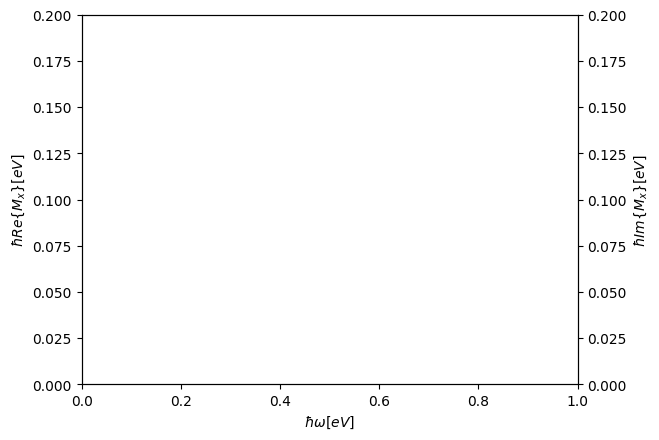

In [29]:
fig, *axs = setup_plot(x_lim=[0, 1], y_lim=[0, 0.2])
integrals = calculate_integral_points(
    mem_fn_op, ss_sum_real, ss_sum_imag, hbar_w_op, T=T_0, K_c=3 * Kf_
)
arrays_to_csv(
    np.array(ws_0.to("cpu")),
    np.array(integrals[0]),
    f"op-g2, real, T={T_0}K, eta={eta_0}eV",
)
arrays_to_csv(
    np.array(ws_0.to("cpu")),
    list(np.array(integrals[1])),
    f"op-g2, imag, T={T_0}K, eta={eta_0}eV",
)
plot_real_and_imag_result(*axs, *integrals, T=T_0)
axs[0].legend(loc="best")
fig.tight_layout()

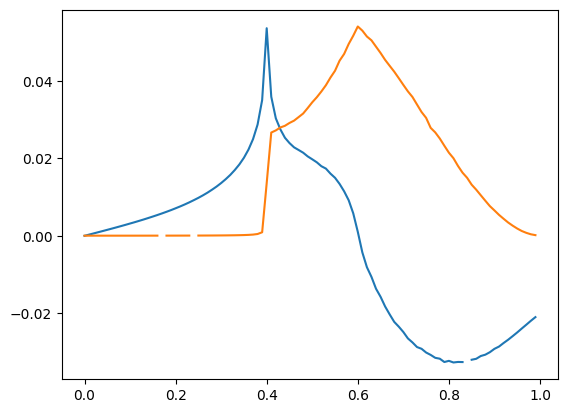

In [12]:
plt.plot(ws_0.to("cpu"), integrals[0])
plt.plot(ws_0.to("cpu"), integrals[1])

## Memorijska funkcija analitički

In [7]:
def mem_fn_imag_anal(hbar_w, e_w, e_c, hbar_w_ph=hbar_w_op, u=Ef):
    faktor = a**3 * G_op2 * vf / (2 * pi * hbar**4 * vf**4)
    e_l = u - hbar_w_ph
    e_r = u + hbar_w_ph
    return (
        faktor
        * hbar  ## pomnoži s hbar da bude u istim jedinicama kao numerika
        * torch.where(hbar_w > hbar_w_ph, 1, 0)
        * torch.where(e_c + hbar_w_ph > hbar_w, 1, 0)
        * (
            (hbar_w + e_l) ** 2
            * torch.where(e_w > hbar_w + e_l, 1, 0)
            * (
                torch.where(hbar_w - hbar_w_ph + 2 * u > e_c, 1, 0)
                * (
                    1
                    + (e_c**2 - (hbar_w - hbar_w_ph) ** 2)
                    / (4 * Ef * (Ef + hbar_w - hbar_w_ph))
                )
                - 1
            )
            ** 2
            + (hbar_w - e_r) ** 2
            * torch.where(e_r > hbar_w, 1, 0)
            * (
                torch.where(torch.abs(hbar_w - hbar_w_ph - 2 * Ef) > e_c, 1, 0)
                * (
                    1
                    + (e_c**2 - (hbar_w - hbar_w_ph) ** 2)
                    / (4 * Ef * (Ef - hbar_w + hbar_w_ph))
                )
                - 1
            )
            ** 2
        )
    )

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Patrik\AppData\Local\Temp\ipykernel_12616\600615019.py:11: SyntaxWarning: invalid escape sequence '\e'
  plt.text(0.2, 0.08, f"$\epsilon _w=${W} eV")
C:\Users\Patrik\AppData\Local\Temp\ipykernel_12616\600615019.py:12: SyntaxWarning: invalid escape sequence '\e'
  plt.text(0.2, 0.075, f"$\epsilon _c={3*float(Ef):.1f}$ eV")
C:\Users\Patrik\AppData\Local\Temp\ipykernel_12616\600615019.py:13: SyntaxWarning: invalid escape sequence '\e'
  plt.text(0.2, 0.07, f"$\epsilon _F={float(Ef):.1f}$ eV")


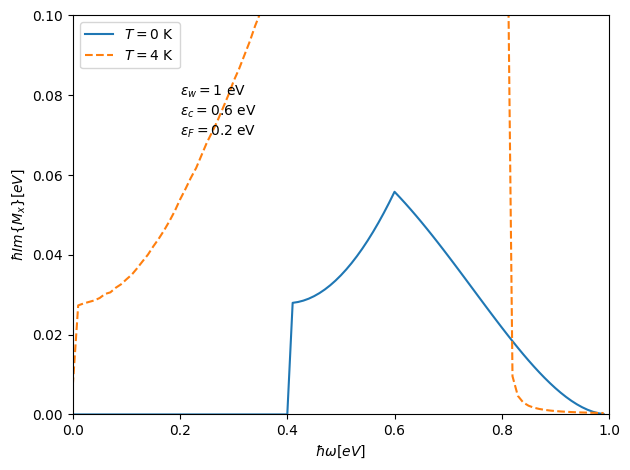

In [31]:
fig, ax = setup_plot(real=False, x_lim=[0, 1], y_lim=[0, 0.1])
values = list(mem_fn_imag_anal(ws_0, W, 3 * Ef).to("cpu"))
plot_result(ax, values, T=0)
numeric_values = read_from_csv("op-g2, imag, T=4K, eta=0.001eV")[1]
ax.plot(
    ws_0[::].to("cpu"),
    numeric_values,
    linestyle="--",
    label=f"$T={T_0}$ K",
)
plt.text(0.2, 0.08, f"$\epsilon _w=${W} eV")
plt.text(0.2, 0.075, f"$\epsilon _c={3*float(Ef):.1f}$ eV")
plt.text(0.2, 0.07, f"$\epsilon _F={float(Ef):.1f}$ eV")

ax.legend(loc="best")
fig.tight_layout()

## Self energija

### Numerički

In [8]:
def selfen_integral(E, hbar_w, e_w, e_c, Ef, T=T_0):
    K = E / hbar / vf * a
    K_w = e_w / hbar / vf * a
    K_c = e_c / hbar / vf * a
    integration_domain = torch.Tensor(
        [
            [0, K_w],
            [-1, 1],
        ]
    )

    def self_en_sum(Q, x):
        sum = 0
        for s in [-1, 1]:
            sum += (
                s * bose_einstein(s * hbar_w_op, T) + s * fermi_dirac(eps(Q), Ef, T)
            ) / (hbar_w + s * hbar_w_op - eps(Q) + eta_0 * 1j)
        return (
            Q**2
            / (2 * pi) ** 3
            * (2 * pi)
            * sum
            * coupling(K_c, torch.sqrt(Q**2 + K**2 - 2 * K * Q * x))
        )

    def integrand(Q):

        return self_en_sum(
            Q[:, 0],
            Q[:, 1],
        ).imag

    integral_k_k_ = tp2.integrate(
        integrand,
        dim=2,
        N=10**6,
        integration_domain=integration_domain,
    )

    return integral_k_k_

c:\Users\Patrik\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
c:\Users\Patrik\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchquad\integration\utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


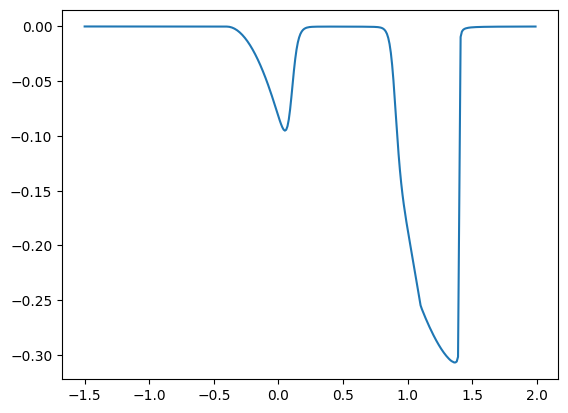

In [12]:
self_integral = [float(selfen_integral(Ef, w, W, C, Ef)) for w in ws_0]
plt.plot(ws_0.to("cpu"), self_integral)

### Analitički

In [13]:
def selfen_anal(E, w, e_c, e_w, Ef):
    return (
        -(a**3)
        * G_op2
        / 2
        / hbar**3
        / pi
        / vf**3
        * (
            torch.where(Ef - w - hbar_w_op > 0, 1, 0)
            * torch.where(w + hbar_w_op > 0, 1, 0)
            * torch.where(Ef - w - hbar_w_op > 0, 1, 0)
            * (w + hbar_w_op)
            * (
                torch.where(e_c - E - w - hbar_w_op > 0, 1, 0) * (w + hbar_w_op)
                + (e_c**2 - (E - w - hbar_w_op) ** 2)
                / (4 * E)
                * torch.where(E + w + hbar_w_op - e_c > 0, 1, 0)
                * torch.where(e_c - abs(E - w - hbar_w_op) > 0, 1, 0)
            )
            + torch.where(e_w - w + hbar_w_op > 0, 1, 0)
            * torch.where(w - hbar_w_op - Ef > 0, 1, 0)
            * torch.where(w - hbar_w_op > 0, 1, 0)
            * (w - hbar_w_op)
            * (
                torch.where(e_c - E - w + hbar_w_op > 0, 1, 0) * (w - hbar_w_op)
                + (e_c**2 - (E - w + hbar_w_op) ** 2)
                / (4 * E)
                * torch.where(E + w - hbar_w_op - e_c > 0, 1, 0)
                * torch.where(e_c - abs(E - w + hbar_w_op) > 0, 1, 0)
            )
        )
    )

<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Patrik\AppData\Local\Temp\ipykernel_8028\2818590799.py:3: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$\hbar \omega (eV)$")
C:\Users\Patrik\AppData\Local\Temp\ipykernel_8028\2818590799.py:4: SyntaxWarning: invalid escape sequence '\S'
  plt.ylabel("$\Sigma_2(E_F,\omega) (eV)$")


Text(0, 0.5, '$\\Sigma_2(E_F,\\omega) (eV)$')

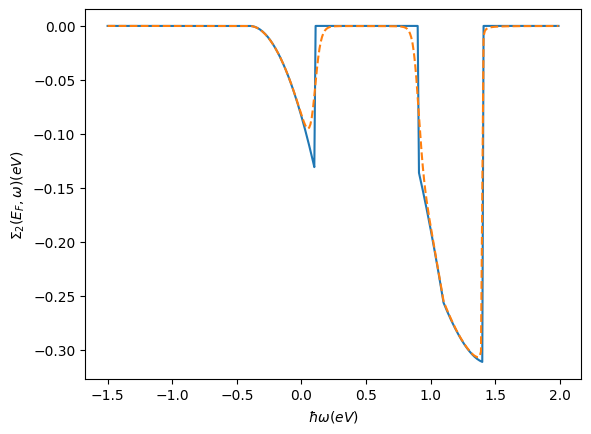

In [14]:
plt.plot(ws_0.cpu(), selfen_anal(Ef, ws_0, C, W, Ef).cpu(), label="Analitički")
plt.plot(ws_0.to("cpu"), self_integral, label="Numerički", linestyle="--")
plt.xlabel("$\hbar \omega (eV)$")
plt.ylabel("$\Sigma_2(E_F,\omega) (eV)$")

## Momentum distribucija 

In [39]:
SELFEN_METHOD = "numerical"
NUM_NE, NUM_NW = 50, 400
NUM_WMIN, NUM_WMAX = -1.5, 2.0
_num_cache = {}


def _lininterp(x, xp, fp):
    x = torch.as_tensor(x, dtype=fp.dtype, device=fp.device).reshape(-1)
    idx = torch.clamp(torch.searchsorted(xp, x), 1, len(xp) - 1)
    x0, x1 = xp[idx - 1], xp[idx]
    t = ((x - x0) / (x1 - x0)).clamp(0, 1)
    return (1 - t) * fp[idx - 1] + t * fp[idx]


def _numerical_table(e_c, e_w, Ef, T):
    dev = Ef.device
    Eg = torch.linspace(0.01, e_w, NUM_NE, device=dev, dtype=torch.float64)
    Wg = torch.linspace(NUM_WMIN, NUM_WMAX, NUM_NW, device=dev, dtype=torch.float64)
    print(
        f"[selfen] building numerical Σ table {NUM_NE}×{NUM_NW} "
        f"(e_c={float(e_c):.3g}, e_w={float(e_w):.3g}) — {NUM_NE*NUM_NW} integrals ..."
    )
    tab = torch.empty(NUM_NE, NUM_NW, device=dev, dtype=torch.float64)
    for i, E in enumerate(Eg):
        for j, wj in enumerate(Wg):
            tab[i, j] = float(
                selfen_integral(float(E), float(wj), e_w, e_c, Ef, T)
            )  # (E, ω, e_w, e_c, Ef)
    print("[selfen] table done.")
    return Eg, Wg, tab


def selfen(E, w, e_c, e_w, Ef=Ef, T=T_0):
    """Im Σ^R(E, ω) ≤ 0.  E: scalar energy;  w: scalar or 1D tensor of ω."""
    if SELFEN_METHOD == "analytical":
        return selfen_anal(E, w, e_c, e_w, Ef)
    elif SELFEN_METHOD == "numerical":
        key = (round(float(e_c), 6), round(float(e_w), 6), round(float(Ef), 6), T)
        if key not in _num_cache:
            _num_cache[key] = _numerical_table(
                torch.as_tensor(e_c), torch.as_tensor(e_w), Ef, T
            )
        Eg, Wg, tab = _num_cache[key]
        Ev = float(E)
        iE = int(
            torch.searchsorted(
                Eg, torch.tensor(Ev, dtype=torch.float64, device=Eg.device)
            ).clamp(1, len(Eg) - 1)
        )
        tE = (Ev - float(Eg[iE - 1])) / float(Eg[iE] - Eg[iE - 1])
        row = (1 - tE) * tab[iE - 1] + tE * tab[iE]  # Σ(E, ·) over Wg
        return _lininterp(w, Wg, row).reshape(torch.as_tensor(w).shape)
    else:
        raise ValueError("SELFEN_METHOD must be 'analytical' or 'numerical'")

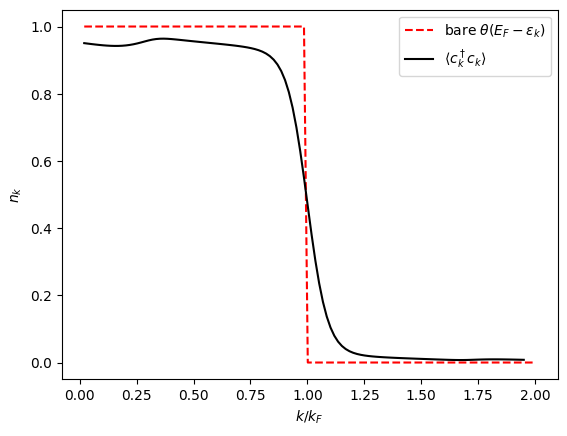

In [18]:
def gamma(K, w, e_c, e_w, Ef, T):
    return -selfen(eps(K), w, e_c, e_w, Ef=Ef, T=T)


def spectral(K, w, e_c, e_w, Ef, T, eta):
    G = gamma(K, w, e_c, e_w, Ef, T) + eta
    return 1 / pi * G / ((w - eps(K)) ** 2 + G**2)


def occupation(K, w_grid, e_c, e_w, Ef, T, eta=eta_0):
    A = spectral(K, w_grid, e_c, e_w, Ef, T, eta)
    f = fermi_dirac(w_grid, Ef, T)
    return torch.trapz(A * f, w_grid) / torch.trapz(A, w_grid)


# keep existing cell names working unchanged:
gamma_anal, spectral_anal, occupation_anal = gamma, spectral, occupation


w_grid = torch.linspace(-1.5, 2, 8000)
kg = torch.linspace(0.02 * Kf_, 2.0 * Kf_, 120)
nk = torch.tensor(
    [occupation_anal(K, w_grid, C, W, Ef=Ef, T=T_0, eta=eta_0) for K in kg]
)
nk_bare = (eps(kg) <= Ef).double()

plt.plot(kg.cpu() / Kf_, nk_bare.cpu(), "r--", label=r"bare $\theta(E_F-\epsilon_k)$")
plt.plot(kg.cpu() / Kf_, nk.cpu(), "k-", label=r"$\langle c^\dagger_k c_k\rangle$")
plt.xlabel("$k/k_F$")
plt.ylabel("$n_k$")
plt.legend()

### Spektralna funkcija i plotovi selfenergije za razne parametre

<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Patrik\AppData\Local\Temp\ipykernel_8028\1447479074.py:18: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$\hbar \omega (eV)$")
C:\Users\Patrik\AppData\Local\Temp\ipykernel_8028\1447479074.py:19: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$A(\omega) (eV^{-1})$")


Text(0, 0.5, '$A(\\omega) (eV^{-1})$')

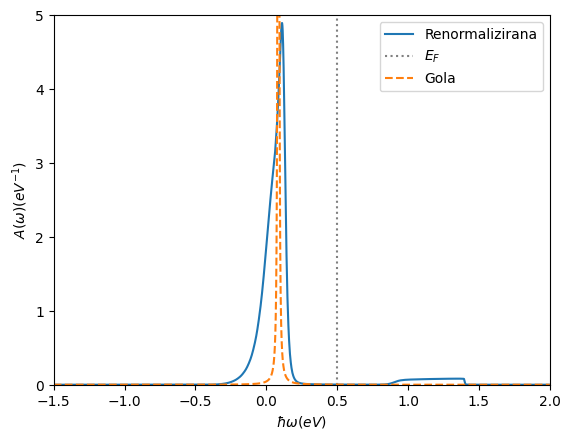

In [26]:
K_toplot = 0.17 * Kf_

plt.plot(
    w_grid.cpu(),
    spectral_anal(K_toplot, w_grid, C, W, Ef=Ef, T=T_0, eta=eta_0).cpu(),
    label="Renormalizirana",
)
plt.ylim(0, 5)
plt.xlim(w_grid[0].cpu(), w_grid[-1].cpu())
plt.axvline(float(Ef), color="gray", ls=":", label="$E_F$")
plt.plot(
    w_grid.cpu(),
    1 / pi * eta_0 / ((w_grid - eps(K_toplot)) ** 2 + eta_0**2).cpu(),
    label="Gola",
    linestyle="--",
)
plt.legend()
plt.xlabel("$\hbar \omega (eV)$")
plt.ylabel("$A(\omega) (eV^{-1})$")

[selfen] building numerical Σ table 50×400 (e_c=1.2, e_w=1) — 20000 integrals ...
[selfen] table done.
[selfen] building numerical Σ table 50×400 (e_c=1.2, e_w=1) — 20000 integrals ...
[selfen] table done.
[selfen] building numerical Σ table 50×400 (e_c=1.2, e_w=1) — 20000 integrals ...
[selfen] table done.


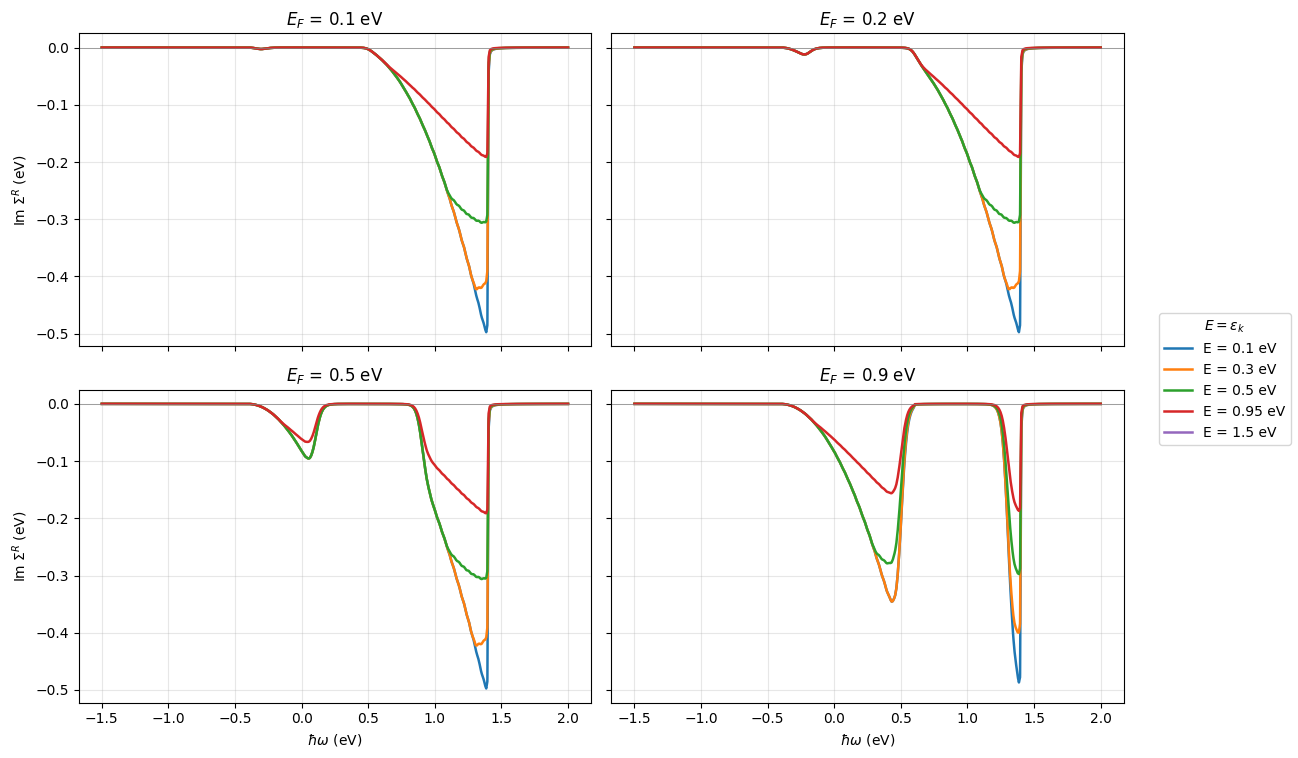

In [29]:
dev = Ef.device
E_list = [0.1, 0.3, 0.5, 0.95, 1.5]  # 5 band-energy curves
Ef_list = [0.1, 0.2, 0.5, 0.9]  # one panel each
colors = plt.cm.tab10(np.arange(len(E_list)))

fig, axs = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, Ef_val in zip(axs.ravel(), Ef_list):
    for E_val, c in zip(E_list, colors):
        y = selfen(
            torch.tensor(E_val, device=dev, dtype=torch.float64),
            w_grid.to(dev),
            C,
            W,
            torch.tensor(Ef_val, device=dev, dtype=torch.float64),
            T=T_0,
        )
        ax.plot(w_grid.cpu(), y.cpu(), color=c, lw=1.8, label=f"E = {E_val} eV")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(f"$E_F$ = {Ef_val} eV")
    ax.grid(alpha=0.3)
for ax in axs[-1, :]:
    ax.set_xlabel(r"$\hbar\omega$ (eV)")
for ax in axs[:, 0]:
    ax.set_ylabel(r"Im $\Sigma^R$ (eV)")

handles, labels = axs[0, 0].get_legend_handles_labels()  # single shared legend
fig.legend(handles, labels, loc="center right", title=r"$E=\epsilon_k$")
fig.tight_layout(rect=[0, 0, 0.88, 0.96])  # leave room on the right
plt.show()

In [38]:
E = torch.linspace(0.01, 1.0, 120, device=dev, dtype=torch.float64)
w = torch.linspace(0.0, 1.6, 150, device=dev, dtype=torch.float64)
EE, WW = torch.meshgrid(E, w, indexing="ij")
Ew, Ww = EE.cpu().numpy(), WW.cpu().numpy()
Ef_list = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
surf = {
    v: (
        -selfen_anal(EE, WW, C, W, torch.tensor(v, device=dev, dtype=torch.float64))
    )  # zasad samo za T=0
    .cpu()
    .numpy()
    for v in Ef_list
}
vmax = max(m.max() for m in surf.values())


def draw(Ef_val=0.5, azim=-125, elev=28):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(
        Ww,
        Ew,
        surf[Ef_val],
        color="0.6",
        edgecolor="none",
        rstride=1,
        cstride=1,
        antialiased=True,
    )  # solid grey
    ax.set_zlim(0, vmax)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel(r"$\hbar\omega$")
    ax.set_ylabel(r"$E$")
    ax.set_zlabel(r"$-$Im$\Sigma$")
    ax.set_title(f"$E_F$ = {Ef_val} eV")
    plt.show()


interact(
    draw,
    Ef_val=Dropdown(options=Ef_list, value=0.5, description="E_F"),
    azim=FloatSlider(min=-180, max=180, step=2, value=-125, description="azim"),
    elev=FloatSlider(min=0, max=90, step=2, value=28, description="elev"),
)

interactive(children=(Dropdown(description='E_F', index=3, options=(0.1, 0.2, 0.3, 0.5, 0.7, 0.9), value=0.5),…

<function __main__.draw(Ef_val=0.5, azim=-125, elev=28)>